<a href="https://colab.research.google.com/github/alaharithapaswi42-spec/machine-learning/blob/main/Adultincome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  cl

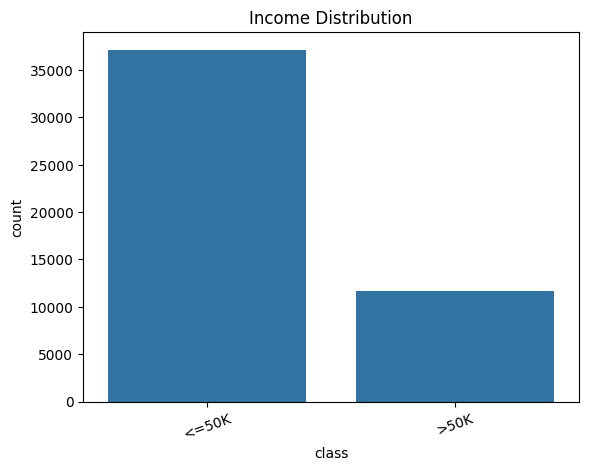

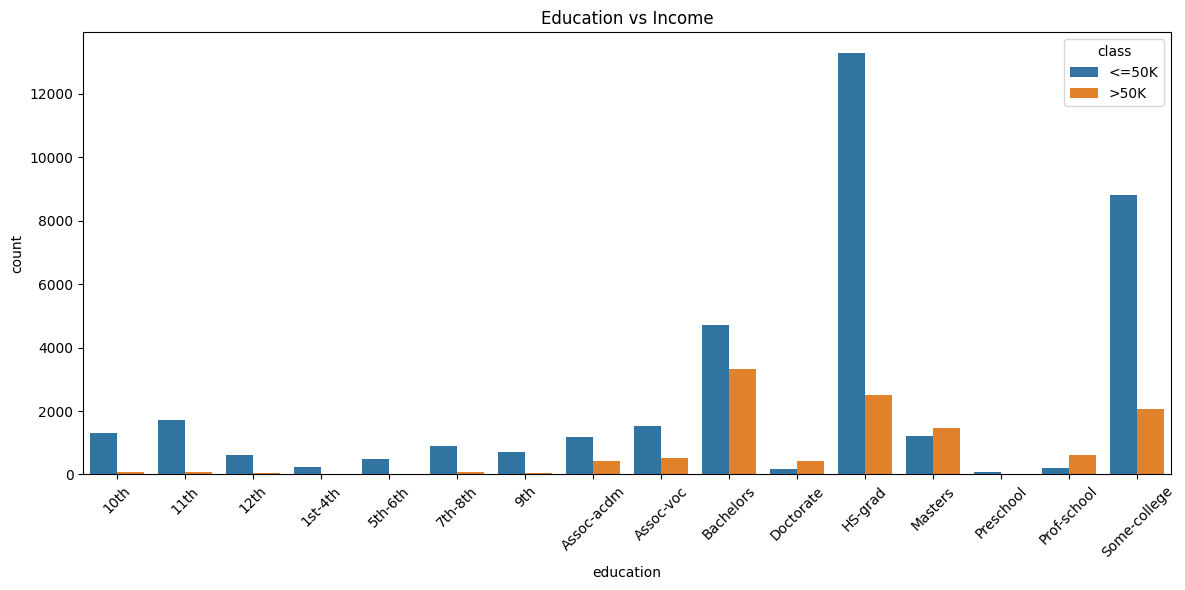

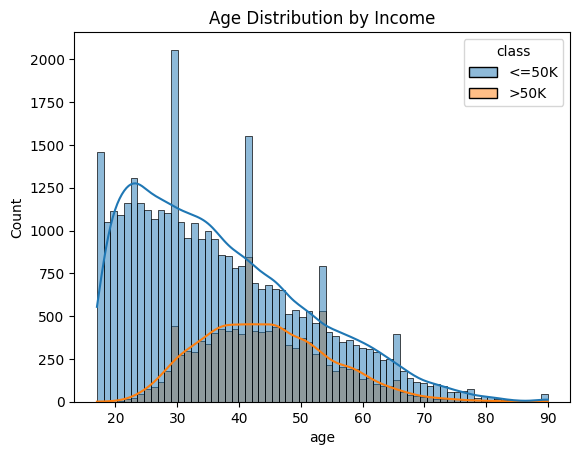

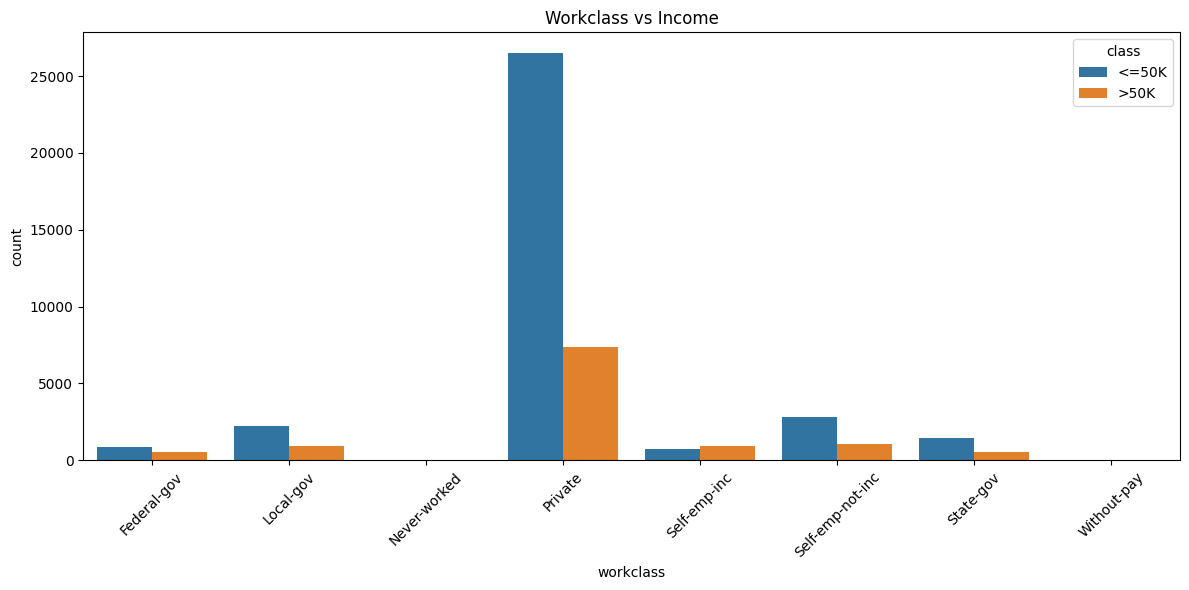


Feature Engineering and EDA completed.


In [6]:
# PROJECT 3: ADULT INCOME - FEATURE ENGINEERING AND EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

# -------------------------------
# Load Adult Dataset
# -------------------------------

adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame

print("First 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# -------------------------------
# Feature Engineering
# -------------------------------

# Age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Age",
        "Senior",
        "Very_Senior"
    ]
)

# Capital gain indicator
df["has_capital_gain"] = (
    df["capital-gain"] > 0
).astype(int)

# Capital loss indicator
df["has_capital_loss"] = (
    df["capital-loss"] > 0
).astype(int)

# -------------------------------
# Income Distribution
# -------------------------------

sns.countplot(data=df, x="class")
plt.title("Income Distribution")
plt.xticks(rotation=20)
plt.show()

# -------------------------------
# Education vs Income
# -------------------------------

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="education",
    hue="class"
)

plt.title("Education vs Income")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# Age Distribution
# -------------------------------

sns.histplot(
    data=df,
    x="age",
    hue="class",
    kde=True
)

plt.title("Age Distribution by Income")
plt.show()

# -------------------------------
# Workclass vs Income
# -------------------------------

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="workclass",
    hue="class"
)

plt.title("Workclass vs Income")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature Engineering and EDA completed.")